# Data Pre processing

In [1]:
!pip install kagglehub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mrwellsdavid/unsw-nb15")

print("Path to dataset files:", path)

100%|██████████| 149M/149M [00:01<00:00, 90.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mrwellsdavid/unsw-nb15/versions/1


In [3]:
import os

os.listdir(path)

['UNSW-NB15_3.csv',
 'UNSW_NB15_testing-set.csv',
 'UNSW-NB15_2.csv',
 'UNSW-NB15_LIST_EVENTS.csv',
 'NUSW-NB15_features.csv',
 'UNSW-NB15_4.csv',
 'UNSW_NB15_training-set.csv',
 'UNSW-NB15_1.csv']

In [4]:
import pandas as pd

df = pd.read_csv(path + "/UNSW_NB15_training-set.csv")
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [5]:
df.shape
df.columns
df['label'].value_counts()
df.dtypes

,0
id,int64
dur,float64
proto,object
service,object
state,object
spkts,int64
dpkts,int64
sbytes,int64
dbytes,int64
rate,float64


In [6]:
df = df.sample(n=25000, random_state=42)

In [7]:
df = df.drop(columns=['attack_cat'])

df = df.drop(columns=['id'])

In [8]:
y = df['label']
X = df.drop(columns=['label'])

In [9]:
X = pd.get_dummies(X, drop_first=True)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(25000, 185)

# Model Training
Isolation Forest

In [11]:
from sklearn.ensemble import IsolationForest

X_normal = X_scaled[y == 0]

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42
)

iso_model.fit(X_normal)

IsolationForest(contamination=0.1, random_state=42)

In [12]:
import numpy as np

scores = iso_model.decision_function(X_scaled)

# Convert to 0–100 risk score (higher = more risky)
ml_risk = 100 * (1 - (scores - scores.min()) / (scores.max() - scores.min()))

print("Min ML risk:", ml_risk.min())
print("Max ML risk:", ml_risk.max())

print("Average ML risk (Normal):", ml_risk[y == 0].mean())
print("Average ML risk (Attack):", ml_risk[y == 1].mean())

Min ML risk: 0.0
Max ML risk: 100.0
Average ML risk (Normal): 24.683029377200533
Average ML risk (Attack): 42.403123924165016


In [13]:
rule_risk = np.zeros(len(df))

# High source bytes
rule_risk += (df['sbytes'] > df['sbytes'].quantile(0.90)) * 20

# High duration
rule_risk += (df['dur'] > df['dur'].quantile(0.90)) * 15

# High packet rate
rule_risk += (df['rate'] > df['rate'].quantile(0.90)) * 20

# High service connection count
rule_risk += (df['ct_srv_src'] > df['ct_srv_src'].quantile(0.90)) * 15

print("Average Rule risk (Normal):", rule_risk[y == 0].mean())
print("Average Rule risk (Attack):", rule_risk[y == 1].mean())

Average Rule risk (Normal): 5.145872129112353
Average Rule risk (Attack): 7.578882168622021


In [14]:
rule_risk_scaled = 100 * (rule_risk - rule_risk.min()) / (rule_risk.max() - rule_risk.min())

final_risk = 0.7 * ml_risk + 0.3 * rule_risk_scaled

print("Average FINAL risk (Normal):", final_risk[y == 0].mean())
print("Average FINAL risk (Attack):", final_risk[y == 1].mean())

Average FINAL risk (Normal): 21.688868103279532
Average FINAL risk (Attack): 36.178371462877244


# Evaluations + Metrics

In [15]:
pred = (final_risk >= 35).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print("Hybrid performance")
print(confusion_matrix(y, pred))
print(classification_report(y, pred))

Hybrid performance
[[9261 2016]
 [7870 5853]]
              precision    recall  f1-score   support

           0       0.54      0.82      0.65     11277
           1       0.74      0.43      0.54     13723

    accuracy                           0.60     25000
   macro avg       0.64      0.62      0.60     25000
weighted avg       0.65      0.60      0.59     25000



In [16]:
ml_pred = (ml_risk >= 50).astype(int)

print("ML-only performance")
print(classification_report(y, ml_pred))

ML-only performance
              precision    recall  f1-score   support

           0       0.53      0.90      0.67     11277
           1       0.81      0.33      0.47     13723

    accuracy                           0.59     25000
   macro avg       0.67      0.62      0.57     25000
weighted avg       0.68      0.59      0.56     25000



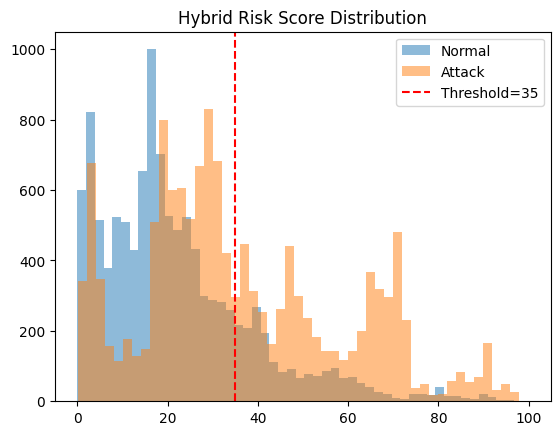

In [17]:
import matplotlib.pyplot as plt

plt.hist(final_risk[y==0], bins=50, alpha=0.5, label="Normal")
plt.hist(final_risk[y==1], bins=50, alpha=0.5, label="Attack")
plt.axvline(x=35, color='red', linestyle='--', label='Threshold=35')
plt.legend()
plt.title("Hybrid Risk Score Distribution")
plt.show()

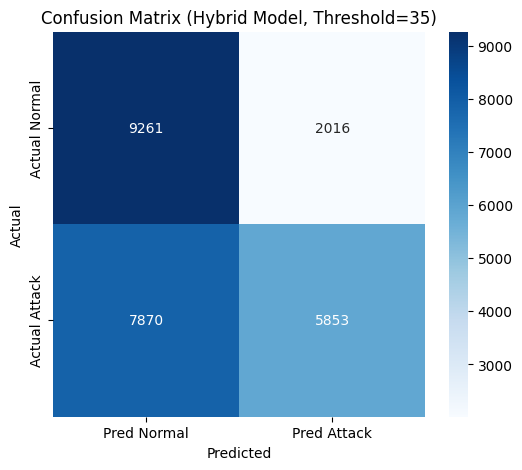

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred Normal","Pred Attack"],
            yticklabels=["Actual Normal","Actual Attack"])
plt.title("Confusion Matrix (Hybrid Model, Threshold=35)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

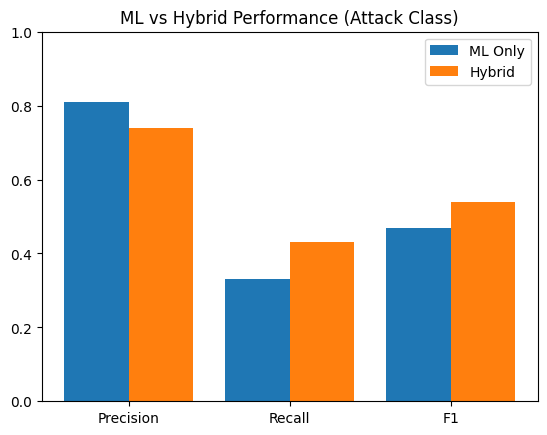

In [19]:
labels = ['Precision', 'Recall', 'F1']

ml_vals = [0.81, 0.33, 0.47]
hybrid_vals = [0.74, 0.43, 0.54]

x = range(len(labels))

plt.bar(x, ml_vals, width=0.4, label='ML Only')
plt.bar([i+0.4 for i in x], hybrid_vals, width=0.4, label='Hybrid')

plt.xticks([i+0.2 for i in x], labels)
plt.ylim(0,1)
plt.legend()
plt.title("ML vs Hybrid Performance (Attack Class)")
plt.show()

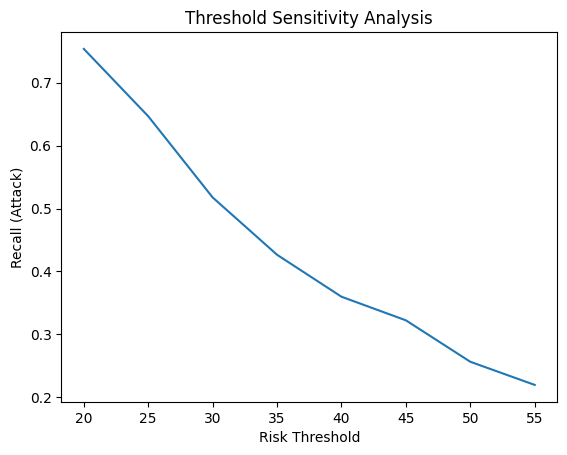

In [20]:
thresholds = range(20, 60, 5)
recalls = []

from sklearn.metrics import recall_score

for t in thresholds:
    preds = (final_risk >= t).astype(int)
    recalls.append(recall_score(y, preds))

plt.plot(thresholds, recalls)
plt.xlabel("Risk Threshold")
plt.ylabel("Recall (Attack)")
plt.title("Threshold Sensitivity Analysis")
plt.show()